In [ ]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from ndsplines import make_interp_spline
import numpy as np
import matplotlib.pyplot as plt
from amplitude import eval2D_bivariate_fp_bspline

In [ ]:
def func_2(x, y):
    return np.sin(x) * np.cos(y)

tx = np.linspace(0, 3, 52)
ty = np.linspace(0, 4, 51)

x_grid, y_grid = np.meshgrid(tx, ty, indexing='ij')
f_values = func_2(x_grid, y_grid)
f_values = np.repeat(f_values[:, :, np.newaxis], 1, axis=2)  # Add a new axis for the spline
ndspl = make_interp_spline((tx, ty), f_values)
coefficients = ndspl.coefficients[:,:,0]

In [ ]:
x_test = np.linspace(0, 3, 100)
y_test = np.full_like(x_test, 2.32487)
f_test_true = func_2(x_test, y_test)

points = np.array([x_test, y_test]).T
f_test = ndspl(points)[:,0]

In [ ]:
f_jax_test = jax.vmap(eval2D_bivariate_fp_bspline, in_axes=(None, None, None, None, None, 0, 0))(
    jnp.asarray(coefficients), 
    jnp.asarray(ndspl.knots[0]), 
    jnp.asarray(ndspl.knots[1]), 
    3,
    3,
    x_test,
    y_test
)

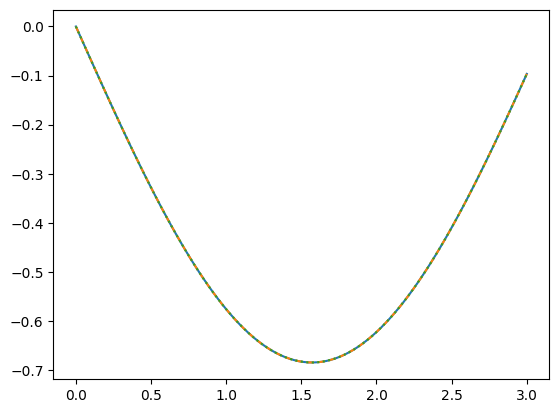

In [ ]:
plt.plot(x_test, f_test_true),
plt.plot(x_test, f_test, ls='--')
plt.plot(x_test, f_jax_test, ls=':')